In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Financial_Fraud_dataset.csv')

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.shape

(6362620, 11)

In [6]:
# Check for nulls and data types
print(df.info())

# Descriptive statistics
display(df.describe())

# Check for missing values explicitly
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00



Missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [ ]:

# Feature overview: count and type classification
feature_summary = pd.DataFrame({
    'Feature': ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg',
                'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest',
                'isFraud', 'isFlaggedFraud'],
    'Type': ['Numerical', 'Categorical', 'Numerical', 'Categorical', 'Numerical',
             'Numerical', 'Categorical', 'Numerical', 'Numerical',
             'Binary (Target)', 'Binary'],
    'Description': [
        'Time step (proxy for time, 1-743)',
        'Transaction type: PAYMENT, TRANSFER, CASH_OUT, DEBIT, CASH_IN',
        'Transaction amount in local currency',
        'Sender account ID',
        'Sender balance before transaction',
        'Sender balance after transaction',
        'Receiver account ID',
        'Receiver balance before transaction',
        'Receiver balance after transaction',
        '1 = Fraud, 0 = Legitimate  <- what we predict',
        '1 = System-flagged fraud (only 16 flagged vs 8,213 actual -- not used)'
    ]
})

numerical   = feature_summary[feature_summary['Type'].str.contains('Numerical')].shape[0]
categorical = feature_summary[feature_summary['Type'] == 'Categorical'].shape[0]
binary      = feature_summary[feature_summary['Type'].str.contains('Binary')].shape[0]

print(f"Total features: {len(feature_summary)}")
print(f"  Numerical:   {numerical}")
print(f"  Categorical: {categorical}")
print(f"  Binary:      {binary}")
print()
print(feature_summary.to_string(index=False))


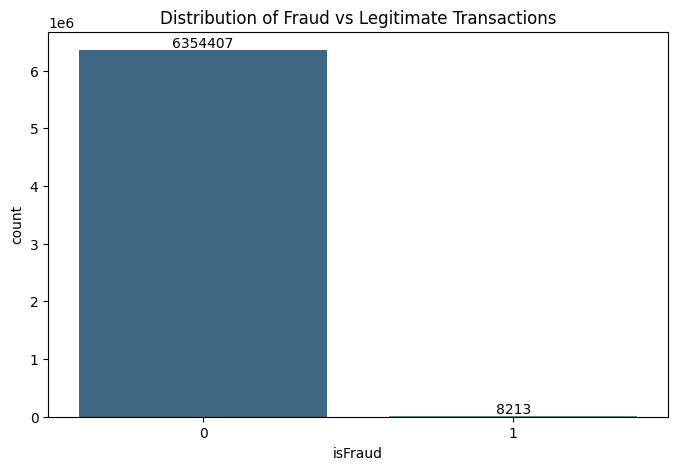

Fraud Percentage: 0.1291%
Legitimate Percentage: 99.8709%


In [8]:
# Distribution of the target variable 'isFraud'
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='isFraud', data=df, palette='viridis')
plt.title('Distribution of Fraud vs Legitimate Transactions')

# Annotate counts
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom'
    )

plt.show()

# Print percentage
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100
print(f"Fraud Percentage: {fraud_pct.get(1, 0):.4f}%")
print(f"Legitimate Percentage: {fraud_pct.get(0, 0):.4f}%")

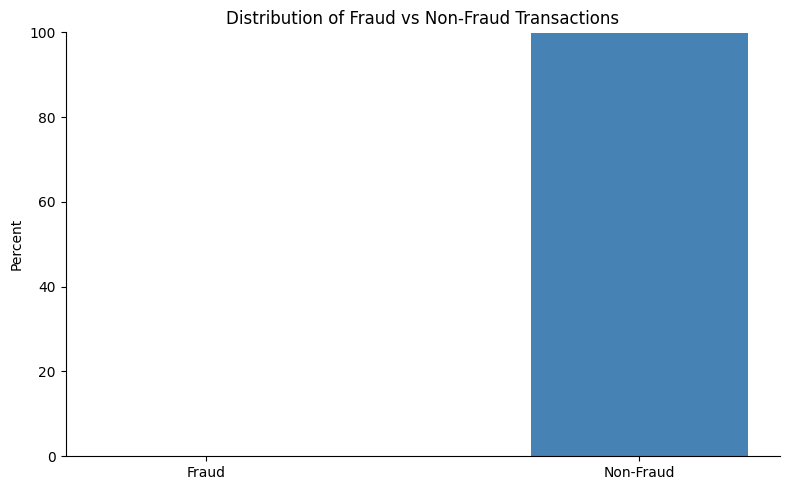

In [18]:

# Percentage distribution of Fraud vs Non-Fraud
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100
labels = ['Fraud', 'Non-Fraud']
values = [fraud_pct[1], fraud_pct[0]]

plt.figure(figsize=(8, 5))
plt.bar(labels, values, color='steelblue', width=0.5)
plt.title('Distribution of Fraud vs Non-Fraud Transactions')
plt.ylabel('Percent')
plt.ylim(0, 100)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


Transaction Type vs Fraud Count:
isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097


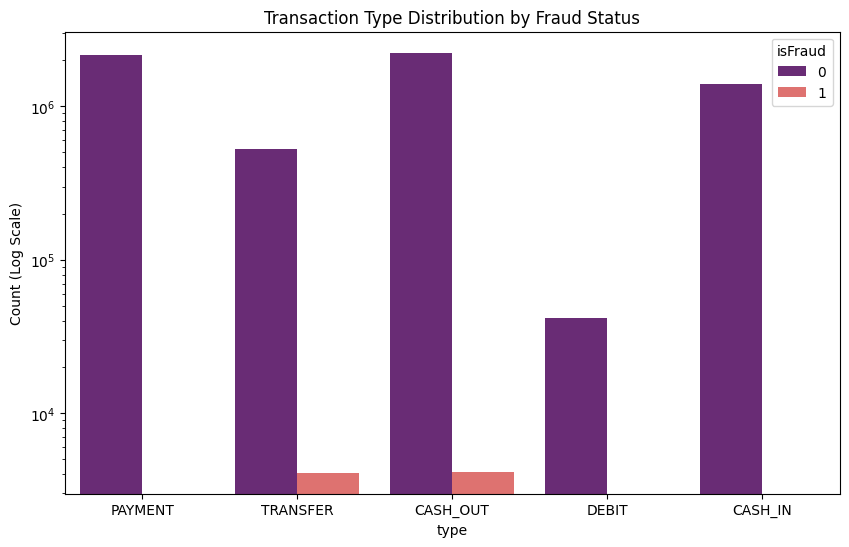

In [9]:
# Cross-tabulate Type and Fraud
type_fraud = pd.crosstab(df['type'], df['isFraud'])
print("Transaction Type vs Fraud Count:")
print(type_fraud)

# Visualization
plt.figure(figsize=(10, 6))
sns.countplot(x='type', hue='isFraud', data=df, palette='magma')
plt.title('Transaction Type Distribution by Fraud Status')
plt.yscale('log') # Log scale because legitimate counts are so much higher
plt.ylabel('Count (Log Scale)')
plt.show()

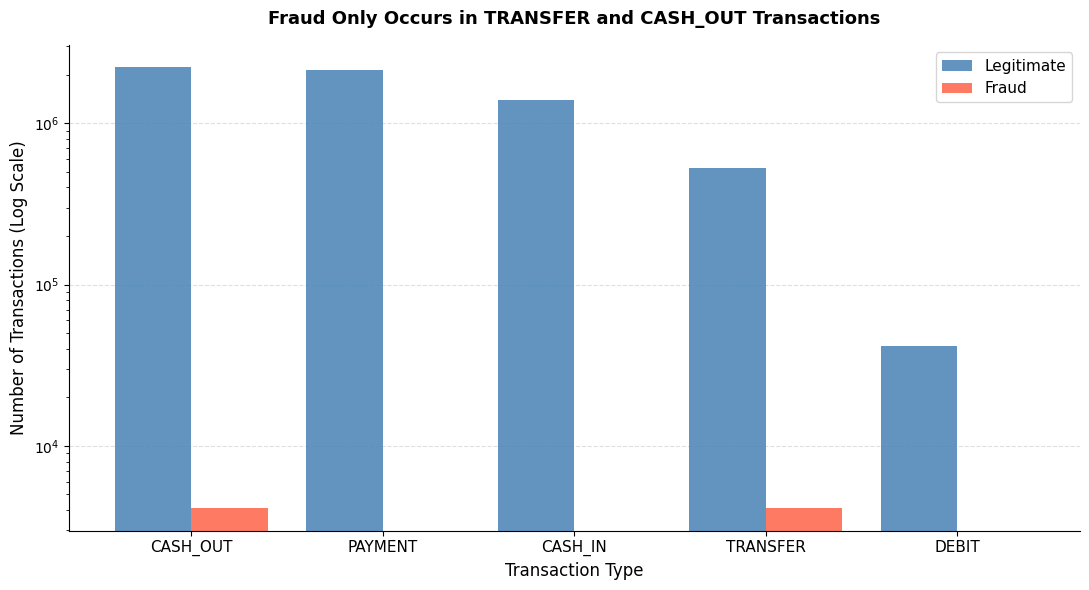

In [16]:

# Cleaner version for non-technical audience
type_fraud = df.groupby('type')['isFraud'].agg(['sum', 'count']).reset_index()
type_fraud.columns = ['type', 'Fraud', 'Total']
type_fraud['Legitimate'] = type_fraud['Total'] - type_fraud['Fraud']
type_fraud['fraud_rate'] = (type_fraud['Fraud'] / type_fraud['Total'] * 100).round(2)

# Sort by total volume
type_fraud = type_fraud.sort_values('Total', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))

x = range(len(type_fraud))
width = 0.4

bars_legit = ax.bar([i - width/2 for i in x], type_fraud['Legitimate'],
                    width=width, label='Legitimate', color='steelblue', alpha=0.85)
bars_fraud = ax.bar([i + width/2 for i in x], type_fraud['Fraud'],
                    width=width, label='Fraud', color='tomato', alpha=0.85)

ax.set_yscale('log')
ax.set_xticks(list(x))
ax.set_xticklabels(type_fraud['type'], fontsize=11)
ax.set_xlabel('Transaction Type', fontsize=12)
ax.set_ylabel('Number of Transactions (Log Scale)', fontsize=12)
ax.set_title('Fraud Only Occurs in TRANSFER and CASH_OUT Transactions',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


In [23]:

# Since fraud only occurs in TRANSFER and CASH_OUT, all models filter to these types
df_filtered = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

print(f"Original dataset:  {df.shape[0]:,} rows  |  Fraud rows: {df['isFraud'].sum():,}  ({df['isFraud'].mean()*100:.4f}%)")
print(f"Filtered dataset:  {df_filtered.shape[0]:,} rows  |  Fraud rows: {df_filtered['isFraud'].sum():,}  ({df_filtered['isFraud'].mean()*100:.4f}%)")
print(f"Rows removed:      {df.shape[0] - df_filtered.shape[0]:,} ({(1 - df_filtered.shape[0]/df.shape[0])*100:.1f}% of data, 0 fraud cases lost)")


Original dataset:  6,362,620 rows  |  Fraud rows: 8,213  (0.1291%)
Filtered dataset:  2,770,409 rows  |  Fraud rows: 8,213  (0.2965%)
Rows removed:      3,592,211 (56.5% of data, 0 fraud cases lost)


In [26]:

# Baseline accuracy: what if we predicted "Not Fraud" for every single transaction?
baseline_full     = (df['isFraud'] == 0).mean() * 100
baseline_filtered = (df_filtered['isFraud'] == 0).mean() * 100

print("Baseline Accuracy (predict all = Not Fraud):")
print(f"Full dataset (6.36M rows): {baseline_full:.4f}%")
print(f"Filtered dataset (2.77M rows): {baseline_filtered:.4f}%")



Baseline Accuracy (predict all = Not Fraud):
Full dataset (6.36M rows): 99.8709%
Filtered dataset (2.77M rows): 99.7035%


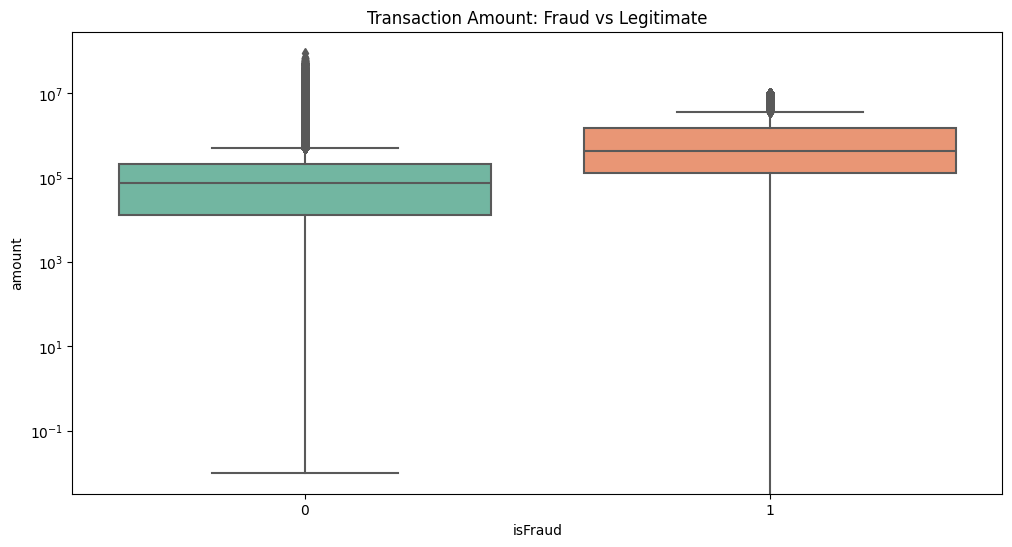

Average Transaction Amount:
isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64


In [10]:
plt.figure(figsize=(12, 6))

# Boxplot to see outliers and distribution
sns.boxplot(x='isFraud', y='amount', data=df, palette='Set2')
plt.title('Transaction Amount: Fraud vs Legitimate')
plt.yscale('log') # Log scale helps deal with extreme outliers
plt.show()

# Check mean amounts
print("Average Transaction Amount:")
print(df.groupby('isFraud')['amount'].mean())

In [11]:
# Calculate balance discrepancies
# For Origin: oldbalanceOrg - amount should = newbalanceOrig
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']

# For Destination: oldbalanceDest + amount should = newbalanceDest
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# View the errors for fraud cases
print("Median Balance Error for Fraud Transactions:")
print(df[df['isFraud'] == 1][['errorBalanceOrig', 'errorBalanceDest']].median())

Median Balance Error for Fraud Transactions:
errorBalanceOrig       0.00
errorBalanceDest    2231.46
dtype: float64


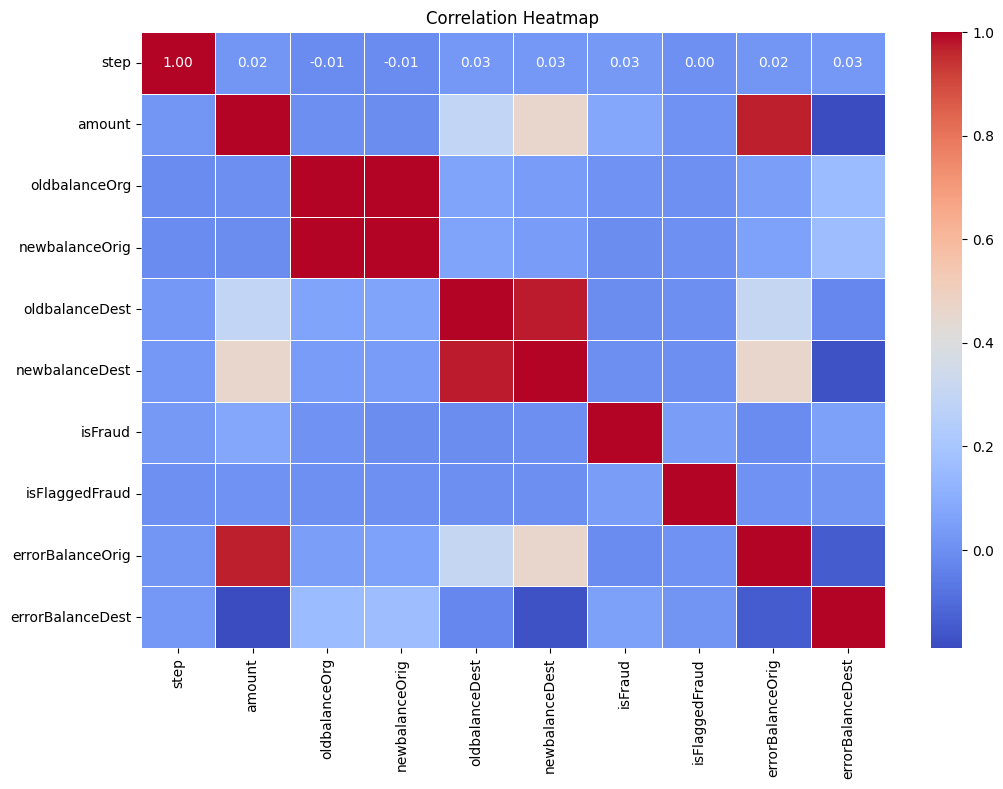

In [12]:
plt.figure(figsize=(12, 8))
# Only include numeric columns for correlation
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [30]:

# ── Feature Engineering ──────────────────────────────────────────────────────
# Applied to the filtered dataset (TRANSFER + CASH_OUT only)
# Same pipeline used in all model notebooks

df_fe = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Encode transaction type: 1 = TRANSFER, 0 = CASH_OUT
df_fe['type_encoded'] = (df_fe['type'] == 'TRANSFER').astype(int)

# Balance discrepancy features
# Legitimate transactions should have errorBalance ≈ 0
df_fe['errorBalanceOrig'] = df_fe['newbalanceOrig'] + df_fe['amount'] - df_fe['oldbalanceOrg']
df_fe['errorBalanceDest'] = df_fe['oldbalanceDest'] + df_fe['amount'] - df_fe['newbalanceDest']

# Binary flags for suspicious account behavior
df_fe['origDrained']   = ((df_fe['newbalanceOrig'] == 0) & (df_fe['oldbalanceOrg'] > 0)).astype(int)
df_fe['destUnchanged'] = (df_fe['newbalanceDest'] == df_fe['oldbalanceDest']).astype(int)

# Log-transform amount to reduce extreme right skew
df_fe['log_amount'] = np.log1p(df_fe['amount'])

FEATURES = [
    'log_amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'errorBalanceDest',
    'origDrained', 'destUnchanged',
    'type_encoded'
]

print(f"Final dataset shape: {df_fe.shape}")
print(f"Features used for modeling ({len(FEATURES)}):\n")
for f in FEATURES:
    print(f"  {f}")

print(f"\nTarget: isFraud  |  Fraud: {df_fe['isFraud'].sum():,} ({df_fe['isFraud'].mean()*100:.4f}%)")


Final dataset shape: (2770409, 17)
Features used for modeling (10):

  log_amount
  oldbalanceOrg
  newbalanceOrig
  oldbalanceDest
  newbalanceDest
  errorBalanceOrig
  errorBalanceDest
  origDrained
  destUnchanged
  type_encoded

Target: isFraud  |  Fraud: 8,213 (0.2965%)
